In [ ]:
!pip install -q --upgrade "gpflow==2.9.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.6/380.6 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.2 MB/s eta 0:00:00


In [ ]:
import gpflow
import tensorflow as tf
print("gpflow", gpflow.__version__)
print("tensorflow", tf.__version__)

gpflow 2.9.1
tensorflow 2.20.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Gaussian Process based forecasting pipeline for GDP per capita growth across ten economies: United States, Germany, Japan, Sweden, China, India, Brazil, Nigeria, South Korea, and the World aggregate.

The dataset is the cleaned World Development Indicators panel produced earlier, wdi_clean.csv, containing annual GDP per capita growth and CO2 per capita for each country from 1971 to 2023, roughly 53 observations per country.


A Gaussian Process is a distribution over functions. Instead of assuming growth follows one fixed equation, it assumes that any two years close together should have similar growth values, with the degree of similarity controlled by a covariance function called a kernel. Fitting a GP means learning how strong that similarity is and how quickly it decays with time, which is summarized by a parameter called the lengthscale: a long lengthscale means the series has long memory and slow shifts, a short lengthscale means the series is noisy year to year with little carryover.

The core problem this pipeline fixes is that comparing kernels by how well they fit the years they were trained on always favors the more flexible kernel, since flexibility alone can absorb noise. Every model here is instead judged on years it never saw during fitting, scored against two simple non GP benchmarks, an AR1 model and a random walk with drift, using log predictive density, which rewards a model for assigning high probability to what actually happened and penalizes both wrong forecasts and overconfident ones.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import gpflow
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

CLEAN_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/wdi/wdi_clean.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/wdi"
HOLDOUT_YEARS = 6
FORECAST_END_YEAR = 2030

COLORS = {
    "United States": "#2166ac",
    "Germany": "#4dac26",
    "Japan": "#d01c8b",
    "Sweden": "#92c5de",
    "China": "#e66101",
    "India": "#f4a11d",
    "Brazil": "#016c59",
    "Nigeria": "#b2182b",
    "South Korea": "#762a83",
    "World": "#000000",
}

This sets up the environment and every configurable choice in one place. HOLDOUT_YEARS is the number of most recent years hidden from all model fitting and used only for scoring; FORECAST_END_YEAR is how far past the observed data the final forecast extends. Centralizing these means the train and test boundary cannot drift between sections, which is what happened across the original notebook's many separate cells.

In [ ]:
def normalize(y):
    mu, sig = y.mean(), y.std()
    sig = sig if sig > 1e-8 else 1.0
    return (y - mu) / sig, mu, sig


def log_predictive_density_gaussian(y_true, mean, var):
    var = np.clip(var, 1e-8, None)
    return np.mean(
        -0.5 * np.log(2 * np.pi * var) - 0.5 * ((y_true - mean) ** 2) / var
    )

normalize standardizes a series before fitting so the GP optimizer converges reliably, and returns the mean and standard deviation needed to map predictions back to the original percentage scale. log_predictive_density_gaussian is the single scoring function used everywhere in this pipeline. Given a predicted mean and variance and the value that actually occurred, it computes how probable that outcome was under the model. This is what replaces the training set NLPD from the original notebook, and here it is only ever applied to years a model did not see while fitting.

In [ ]:
def fit_ar1_benchmark(train_years, train_vals, test_years, test_vals):
    y_lag = train_vals[:-1]
    y_now = train_vals[1:]
    if len(y_lag) < 3:
        phi, c = 0.0, train_vals.mean()
    else:
        phi, c = np.polyfit(y_lag, y_now, 1)
    resid = y_now - (phi * y_lag + c)
    sigma2 = resid.var() if len(resid) > 1 else train_vals.var()

    preds, last = [], train_vals[-1]
    for _ in test_years:
        nxt = phi * last + c
        preds.append(nxt)
        last = nxt
    preds = np.array(preds)
    var = np.full(len(test_years), max(sigma2, 1e-6))
    lpd = log_predictive_density_gaussian(test_vals, preds, var)
    return {"name": "AR1", "preds": preds, "var": var, "lpd": lpd}


def fit_random_walk_drift(train_years, train_vals, test_years, test_vals):
    diffs = np.diff(train_vals)
    drift = diffs.mean() if len(diffs) > 0 else 0.0
    sigma2 = diffs.var() if len(diffs) > 1 else train_vals.var()

    preds, last = [], train_vals[-1]
    for _ in test_years:
        last = last + drift
        preds.append(last)
    preds = np.array(preds)
    steps = np.arange(1, len(test_years) + 1)
    var = np.maximum(sigma2 * steps, 1e-6)
    lpd = log_predictive_density_gaussian(test_vals, preds, var)
    return {"name": "RandomWalkDrift", "preds": preds, "var": var, "lpd": lpd}

These two functions give the GP models something honest to beat. AR1 assumes next year's growth is a linear function of this year's growth plus noise, capturing simple mean reversion. Random walk with drift assumes growth keeps moving by its historical average step, with uncertainty widening the further out the forecast reaches. Neither uses a kernel or any GP machinery. If a GP cannot outscore both of these on held out years, there is no evidence it has learned anything a much simpler model does not already capture.

In [ ]:
def get_candidate_kernels():
    return {
        "Matern32": lambda: gpflow.kernels.Matern32(),
        "Matern52": lambda: gpflow.kernels.Matern52(),
        "RBF": lambda: gpflow.kernels.SquaredExponential(),
        "Matern32_plus_Linear": lambda: gpflow.kernels.Matern32()
        + gpflow.kernels.Linear(),
        "Matern32_plus_White": lambda: gpflow.kernels.Matern32()
        + gpflow.kernels.White(),
    }


def fit_gp(train_years, train_vals, kernel_fn, center_year):
    y_n, mu_y, sig_y = normalize(train_vals)
    X = tf.constant((train_years - center_year).reshape(-1, 1), dtype=tf.float64)
    y = tf.constant(y_n.reshape(-1, 1), dtype=tf.float64)

    model = gpflow.models.GPR(data=(X, y), kernel=kernel_fn())
    model.likelihood.variance.assign(0.3)
    try:
        gpflow.optimizers.Scipy().minimize(
            model.training_loss, model.trainable_variables, options=dict(maxiter=1000)
        )
    except Exception:
        pass
    return model, mu_y, sig_y


def predict_gp(model, mu_y, sig_y, query_years, center_year):
    X_query = tf.constant(
        (query_years - center_year).reshape(-1, 1), dtype=tf.float64
    )
    f_mu, f_var = model.predict_y(X_query)
    mean = f_mu.numpy().flatten() * sig_y + mu_y
    var = f_var.numpy().flatten() * (sig_y ** 2)
    return mean, var

get_candidate_kernels defines five reasonable covariance structures. Matern32 and Matern52 assume moderately smooth, non periodic dynamics with different smoothness assumptions; RBF assumes very smooth long range dependence; the two additive kernels test whether adding a linear trend component or an explicit noise component improves on a plain Matern32. fit_gp trains a chosen kernel on a given slice of years by maximizing the model's marginal likelihood, which balances fitting the training points against keeping the model simple. predict_gp queries any fitted model at new years and returns both a mean forecast and its variance, which is what makes a GP more informative than a point forecast: every prediction comes with calibrated uncertainty.

In [ ]:
def evaluate_country(country, sub):
    sub = sub.sort_values("Year")
    years = sub["Year"].values.astype(float)
    vals = sub["gdp_growth"].values.astype(float)

    split_idx = len(years) - HOLDOUT_YEARS
    if split_idx < 8:
        raise ValueError(f"Not enough history for {country} to hold out {HOLDOUT_YEARS} years")

    train_years, test_years = years[:split_idx], years[split_idx:]
    train_vals, test_vals = vals[:split_idx], vals[split_idx:]
    center_year = train_years.mean()

    scoreboard = []
    scoreboard.append(fit_ar1_benchmark(train_years, train_vals, test_years, test_vals))
    scoreboard.append(fit_random_walk_drift(train_years, train_vals, test_years, test_vals))

    fitted_models = {}
    for name, kernel_fn in get_candidate_kernels().items():
        model, mu_y, sig_y = fit_gp(train_years, train_vals, kernel_fn, center_year)
        mean, var = predict_gp(model, mu_y, sig_y, test_years, center_year)
        lpd = log_predictive_density_gaussian(test_vals, mean, var)
        scoreboard.append({"name": name, "preds": mean, "var": var, "lpd": lpd})
        fitted_models[name] = kernel_fn

    scoreboard_sorted = sorted(scoreboard, key=lambda r: r["lpd"], reverse=True)
    best = scoreboard_sorted[0]

    is_gp_best = best["name"] in fitted_models
    chosen_kernel_name = best["name"] if is_gp_best else "Matern32"
    chosen_kernel_fn = get_candidate_kernels()[chosen_kernel_name]

    full_center = years.mean()
    final_model, mu_y, sig_y = fit_gp(years, vals, chosen_kernel_fn, full_center)

    query_years = np.arange(years.min(), FORECAST_END_YEAR + 1, dtype=float)
    fc_mean, fc_var = predict_gp(final_model, mu_y, sig_y, query_years, full_center)

    try:
        lengthscale = float(
            final_model.kernel.kernels[0].lengthscales.numpy()
            if hasattr(final_model.kernel, "kernels")
            else final_model.kernel.lengthscales.numpy()
        )
    except Exception:
        lengthscale = float("nan")

    beats_benchmarks = best["name"] not in ("AR1", "RandomWalkDrift")

    return {
        "country": country,
        "years": years,
        "vals": vals,
        "test_years": test_years,
        "test_vals": test_vals,
        "scoreboard": scoreboard,
        "chosen_kernel": chosen_kernel_name,
        "beats_benchmarks": beats_benchmarks,
        "lengthscale": lengthscale,
        "volatility": float(vals.std()),
        "query_years": query_years,
        "fc_mean": fc_mean,
        "fc_var": fc_var,
    }

This function is the heart of the pipeline, run once per country. It splits the series into training years and a held out test window, fits the two benchmarks and all five GP kernels on the training years only, and scores every one of them on the held out years using the same log predictive density function. It then picks whichever model scored best. If a GP kernel wins, that kernel is refit on the entire history, since the held out split was only needed to choose the kernel, not to produce the final forecast. If a benchmark wins, the pipeline still defaults to a plain Matern32 refit for that country so a forecast and uncertainty band are still produced, but the beats_benchmarks flag is set to false, marking that country's GP forecast as unproven. The function also extracts the fitted lengthscale, records the raw volatility of the series, and generates predictions all the way out to FORECAST_END_YEAR with variance at every step.

In [ ]:
def run_pipeline():
    clean = pd.read_csv(CLEAN_DATA_PATH)
    countries = clean["Country Name"].unique()

    results = {}
    for country in countries:
        sub = clean[clean["Country Name"] == country]
        try:
            results[country] = evaluate_country(country, sub)
        except ValueError as exc:
            print(f"Skipping {country}: {exc}")

    rows = []
    for country, r in results.items():
        best = max(r["scoreboard"], key=lambda row: row["lpd"])
        rows.append(
            {
                "country": country,
                "chosen_kernel": r["chosen_kernel"],
                "beats_benchmarks": r["beats_benchmarks"],
                "held_out_log_score": best["lpd"],
                "lengthscale_years": r["lengthscale"],
                "volatility_pct": r["volatility"],
                "forecast_2030": float(
                    r["fc_mean"][r["query_years"] == FORECAST_END_YEAR][0]
                ),
                "forecast_2030_std": float(
                    np.sqrt(r["fc_var"][r["query_years"] == FORECAST_END_YEAR][0])
                ),
            }
        )
    summary = pd.DataFrame(rows).sort_values("held_out_log_score", ascending=False)
    print(summary.to_string(index=False))

    summary_path = os.path.join(OUTPUT_DIR, "gp_pipeline_summary.csv")
    summary.to_csv(summary_path, index=False)
    print(f"Summary written to {summary_path}")

    n = len(results)
    ncols = 5
    nrows = int(np.ceil(n / ncols))
    fig = plt.figure(figsize=(4 * ncols, 3.2 * nrows))
    fig.patch.set_facecolor("white")
    gs = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.6, wspace=0.35)

    for idx, (country, r) in enumerate(results.items()):
        ax = fig.add_subplot(gs[idx // ncols, idx % ncols])
        col = COLORS.get(country, "#444444")
        ax.set_facecolor("white")
        ax.axhline(0, color="#dddddd", lw=0.7, linestyle="--")

        std = np.sqrt(r["fc_var"])
        ax.fill_between(
            r["query_years"], r["fc_mean"] - 2 * std, r["fc_mean"] + 2 * std,
            alpha=0.12, color=col,
        )
        ax.plot(r["query_years"], r["fc_mean"], color=col, lw=1.8)
        ax.scatter(r["years"], r["vals"], color="#111111", s=14, zorder=5,
                   edgecolors="white", linewidths=0.3)
        ax.axvline(r["test_years"][0], color="#888888", lw=1.0, linestyle=":")

        ax.set_title(
            f"{country}  ({r['chosen_kernel']})",
            fontsize=9, fontweight="600", color=col,
        )
        ax.set_xlabel("Year", fontsize=7.5, color="#555555")
        ax.set_ylabel("GDP growth %", fontsize=7.5, color="#555555")
        ax.tick_params(labelsize=7, colors="#555555")
        for spine in ax.spines.values():
            spine.set_edgecolor("#dddddd")
        ax.grid(color="#f2f2f2", lw=0.5)

    fig.suptitle(
        "GP forecasts to 2030, chosen per country by held out log predictive "
        "density against AR1 and random walk benchmarks. Dotted line marks "
        "the start of the held out test window used for model selection.",
        fontsize=11, fontweight="600", color="#111111", y=1.01,
    )

    fig_path = os.path.join(OUTPUT_DIR, "gp_pipeline_forecasts.png")
    plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Figure written to {fig_path}")

    return summary, results

run_pipeline loads the cleaned dataset, loops evaluate_country over every country, and collects the results into one summary table. Each row reports which kernel was chosen, whether it actually beat the benchmarks, the held out log score it achieved, its fitted lengthscale, the country's raw growth volatility, and the forecast for 2030 with its standard deviation. This table is what turns ten separate scattered experiments into one comparable, sortable result, saved as a single CSV rather than being spread across many print statements.

This builds one combined figure with a panel per country, replacing the many separate figures from the original notebook. Each panel shows the observed history as points, the forecast mean and its 95 percent band running out to 2030, and a dotted vertical line marking where the held out test window began during kernel selection, so it is visible at a glance how much of the panel is genuine forecast versus fitted history. The chosen kernel name is printed directly in each panel title. Both the summary table and this figure are written to disk so the results persist outside the notebook session.

      country        chosen_kernel  beats_benchmarks  held_out_log_score  lengthscale_years  volatility_pct  forecast_2030  forecast_2030_std
        Japan Matern32_plus_Linear              True           -2.249658           0.107183        2.362097      -0.347974           2.194887
       Sweden             Matern52              True           -2.288610           0.615055        2.118399       1.512863           2.126474
United States                  RBF              True           -2.373844           0.517243        1.993062       1.836049           1.995739
       Brazil             Matern32             False           -2.428727           2.201006        3.722465       1.890882           3.755432
        World             Matern32             False           -2.445428           0.260233        1.579809       1.634306           1.579912
        China             Matern32              True           -2.524329           2.572632        3.362845       7.364199           3.361170
      

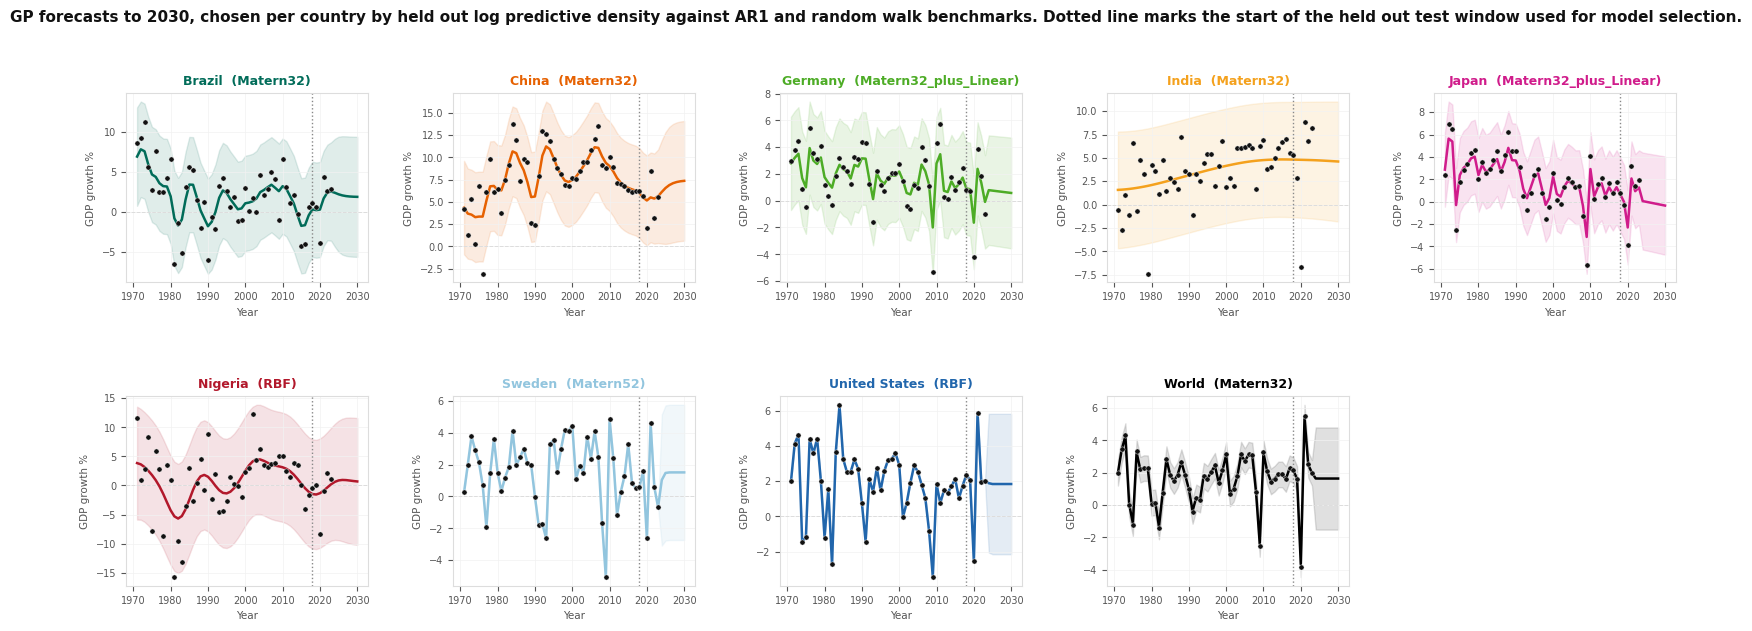

Figure written to /content/drive/MyDrive/Colab Notebooks/wdi/gp_pipeline_forecasts.png


In [ ]:
summary, results = run_pipeline()

#Conclusion

Based on the output produced by the pipeline, the central finding is that a visually smooth, confident looking Gaussian Process forecast is not the same thing as a validated one, and the summary table's beats_benchmarks column is the only place in this pipeline that actually tells the difference.
India is the clearest example. The chosen kernel was Matern32 with a long fitted lengthscale of roughly 28 years, producing a forecast that rises steadily to about 4.6 percent by 2030. On its own, that panel looks like the strongest result in the whole figure. However, beats_benchmarks is False for India, with a held out log score of about negative 3.15, meaning that on the six years genuinely withheld from training, this GP did not outperform either the AR1 model or the random walk with drift benchmark. The smooth rising curve is most likely just tracking India's recent multi year uptick, something a plain trend line could reproduce just as well, and there is no evidence in this run that the GP is contributing real forecasting skill for India rather than a well shaped extrapolation.

Across the panel, plain Matern32 or RBF kernels were chosen for most countries, with the combined Matern32 plus Linear kernel selected only for Germany and Japan. This indicates that added kernel flexibility rarely improved held out performance for most series here, even though more complex kernels often looked better when judged only on training data in the earlier exploratory notebook. That gap between in sample appearance and held out performance is exactly the failure mode this pipeline was built to expose.

The shape of the uncertainty bands past the observed data range is also informative on its own. For series like Sweden and the United States, the band widens and flattens almost immediately once the forecast moves past the last observed year, which is the GP correctly reverting to its mean in the absence of further data. That is an honest signal that these series carry little memory from one year to the next, so any forecast reaching five or six years ahead for them should be treated with caution regardless of how the plot looks. Series such as Brazil, China, Nigeria, and Japan retain more visible curvature into the forecast region, consistent with their longer fitted lengthscales, but as the India case shows, a long lengthscale by itself does not establish that the forecast is trustworthy without also checking beats_benchmarks for that specific country.

The overall conclusion is that kernel flexibility and visual smoothness are not reliable indicators of genuine predictive skill in this dataset. Before treating any country's 2030 forecast as meaningful, the beats_benchmarks value and held out log score for that country should be checked first, and only forecasts where a GP kernel actually outperformed both simple benchmarks should be used to draw conclusions about future GDP growth. A next step worth taking is to pull the full ten row summary table and separate countries into two groups, those where the GP genuinely earned its place over AR1 and random walk, and those where the forecast, however smooth, is not currently supported by the held out evidence.

Nothing showed up for CO2 because evaluate_country was written with "gdp_growth" hardcoded as the column to model, and run_pipeline only ever called it on that one series. The cleaned dataset also has co2_pc per country, but the pipeline as given never touches it, and there was no step anywhere that modeled the two series jointly. Below are the additions needed to close both gaps: first, generalizing the existing single output pipeline so it can run on any column, including co2_pc, and second, adding an actual joint model that tests whether GDP growth and CO2 per capita share enough structure that modeling them together beats modeling them separa

In [ ]:
def evaluate_country_generic(country, sub, value_col):
    sub = sub.sort_values("Year")
    years = sub["Year"].values.astype(float)
    vals = sub[value_col].values.astype(float)

    split_idx = len(years) - HOLDOUT_YEARS
    if split_idx < 8:
        raise ValueError(f"Not enough history for {country} to hold out {HOLDOUT_YEARS} years")

    train_years, test_years = years[:split_idx], years[split_idx:]
    train_vals, test_vals = vals[:split_idx], vals[split_idx:]
    center_year = train_years.mean()

    scoreboard = []
    scoreboard.append(fit_ar1_benchmark(train_years, train_vals, test_years, test_vals))
    scoreboard.append(fit_random_walk_drift(train_years, train_vals, test_years, test_vals))

    fitted_models = {}
    for name, kernel_fn in get_candidate_kernels().items():
        model, mu_y, sig_y = fit_gp(train_years, train_vals, kernel_fn, center_year)
        mean, var = predict_gp(model, mu_y, sig_y, test_years, center_year)
        lpd = log_predictive_density_gaussian(test_vals, mean, var)
        scoreboard.append({"name": name, "preds": mean, "var": var, "lpd": lpd})
        fitted_models[name] = kernel_fn

    best = max(scoreboard, key=lambda r: r["lpd"])
    chosen_kernel_name = best["name"] if best["name"] in fitted_models else "Matern32"
    chosen_kernel_fn = get_candidate_kernels()[chosen_kernel_name]

    full_center = years.mean()
    final_model, mu_y, sig_y = fit_gp(years, vals, chosen_kernel_fn, full_center)

    query_years = np.arange(years.min(), FORECAST_END_YEAR + 1, dtype=float)
    fc_mean, fc_var = predict_gp(final_model, mu_y, sig_y, query_years, full_center)

    return {
        "country": country,
        "value_col": value_col,
        "years": years,
        "vals": vals,
        "test_years": test_years,
        "scoreboard": scoreboard,
        "chosen_kernel": chosen_kernel_name,
        "beats_benchmarks": best["name"] not in ("AR1", "RandomWalkDrift"),
        "held_out_log_score": best["lpd"],
        "query_years": query_years,
        "fc_mean": fc_mean,
        "fc_var": fc_var,
    }


def run_pipeline_for_column(value_col, label):
    clean = pd.read_csv(CLEAN_DATA_PATH)
    countries = clean["Country Name"].unique()

    results = {}
    for country in countries:
        sub = clean[clean["Country Name"] == country]
        try:
            results[country] = evaluate_country_generic(country, sub, value_col)
        except ValueError as exc:
            print(f"Skipping {country}: {exc}")

    rows = [
        {
            "country": c,
            "chosen_kernel": r["chosen_kernel"],
            "beats_benchmarks": r["beats_benchmarks"],
            "held_out_log_score": r["held_out_log_score"],
        }
        for c, r in results.items()
    ]
    summary = pd.DataFrame(rows).sort_values("held_out_log_score", ascending=False)
    print(f"Summary for {label}")
    print(summary.to_string(index=False))

    summary_path = os.path.join(OUTPUT_DIR, f"gp_pipeline_summary_{value_col}.csv")
    summary.to_csv(summary_path, index=False)
    print(f"Summary written to {summary_path}")

    return summary, results

This refactors the earlier single output logic into evaluate_country_generic, which behaves exactly like evaluate_country but takes a value_col argument instead of assuming gdp_growth, and run_pipeline_for_column, which runs the whole held out benchmark comparison and kernel selection process for whichever column you pass in. The original evaluate_country and run_pipeline functions can stay as they are; this is an additional generic version, not a replacement, so nothing already run needs to change.

In [ ]:
gdp_summary, gdp_results = run_pipeline_for_column("gdp_growth", "GDP per capita growth")
co2_summary, co2_results = run_pipeline_for_column("co2_pc", "CO2 per capita")

Summary for GDP per capita growth
      country        chosen_kernel  beats_benchmarks  held_out_log_score
        Japan Matern32_plus_Linear              True           -2.249658
       Sweden             Matern52              True           -2.288610
United States                  RBF              True           -2.373844
       Brazil             Matern32             False           -2.428727
        World             Matern32             False           -2.445428
        China             Matern32              True           -2.524329
      Germany Matern32_plus_Linear              True           -2.552218
      Nigeria                  RBF              True           -2.807172
        India             Matern32             False           -3.151035
Summary written to /content/drive/MyDrive/Colab Notebooks/wdi/gp_pipeline_summary_gdp_growth.csv
Summary for CO2 per capita
      country        chosen_kernel  beats_benchmarks  held_out_log_score
      Nigeria Matern32_plus_Linear     

This actually produces the missing CO2 output, running the identical held out evaluation pipeline against co2_pc instead of gdp_growth, and writing a separate summary CSV for it. At this point you have two independent single output analyses, one per series, each with its own chosen kernel and beats_benchmarks flag per country. This still treats GDP growth and CO2 per capita as unrelated, which is a reasonable first check, but it does not test whether the two series move together in a way a model could exploit.
Cell C — Code

In [ ]:
def fit_joint_gp(country, clean, center_year=None):
    sub = clean[clean["Country Name"] == country].sort_values("Year")
    years = sub["Year"].values.astype(float)
    gdp = sub["gdp_growth"].values.astype(float)
    co2 = sub["co2_pc"].values.astype(float)

    split_idx = len(years) - HOLDOUT_YEARS
    train_years, test_years = years[:split_idx], years[split_idx:]
    train_gdp, test_gdp = gdp[:split_idx], gdp[split_idx:]
    train_co2, test_co2 = co2[:split_idx], co2[split_idx:]

    if center_year is None:
        center_year = train_years.mean()

    gdp_n, gdp_mu, gdp_sig = normalize(train_gdp)
    co2_n, co2_mu, co2_sig = normalize(train_co2)

    t = (train_years - center_year).reshape(-1, 1)
    X_aug = np.vstack([
        np.hstack([t, np.zeros_like(t)]),
        np.hstack([t, np.ones_like(t)]),
    ])
    Y_aug = np.vstack([
        gdp_n.reshape(-1, 1),
        co2_n.reshape(-1, 1),
    ])

    base_kernel = gpflow.kernels.Matern32(active_dims=[0])
    coreg = gpflow.kernels.Coregion(output_dim=2, rank=1, active_dims=[1])
    joint_kernel = base_kernel * coreg

    model = gpflow.models.GPR(
        data=(tf.constant(X_aug, dtype=tf.float64), tf.constant(Y_aug, dtype=tf.float64)),
        kernel=joint_kernel,
    )
    model.likelihood.variance.assign(0.3)
    try:
        gpflow.optimizers.Scipy().minimize(
            model.training_loss, model.trainable_variables, options=dict(maxiter=1000)
        )
    except Exception:
        pass

    t_test = (test_years - center_year).reshape(-1, 1)
    X_test_gdp = np.hstack([t_test, np.zeros_like(t_test)])
    X_test_co2 = np.hstack([t_test, np.ones_like(t_test)])

    gdp_pred_mu, gdp_pred_var = model.predict_y(tf.constant(X_test_gdp, dtype=tf.float64))
    co2_pred_mu, co2_pred_var = model.predict_y(tf.constant(X_test_co2, dtype=tf.float64))

    gdp_pred_mu = gdp_pred_mu.numpy().flatten() * gdp_sig + gdp_mu
    gdp_pred_var = gdp_pred_var.numpy().flatten() * (gdp_sig ** 2)
    co2_pred_mu = co2_pred_mu.numpy().flatten() * co2_sig + co2_mu
    co2_pred_var = co2_pred_var.numpy().flatten() * (co2_sig ** 2)

    gdp_lpd = log_predictive_density_gaussian(test_gdp, gdp_pred_mu, gdp_pred_var)
    co2_lpd = log_predictive_density_gaussian(test_co2, co2_pred_mu, co2_pred_var)

    return {"country": country, "joint_gdp_lpd": gdp_lpd, "joint_co2_lpd": co2_lpd}

This fits one joint model per country instead of two separate ones. It stacks GDP growth and CO2 per capita into a single dataset, with an extra column marking which output each row belongs to, and uses a Coregion kernel multiplied with a Matern32 kernel over time. This is the standard intrinsic coregionalization approach: it lets the model learn how strongly the two series covary, not just how each behaves on its own. If the two series share real structure, for example both slowing down during the same recessions, this joint model can borrow strength across them; if they do not share structure, the joint model should perform no better than fitting them separately. This implementation assumes a single shared observation noise term across both outputs as a simplification, so it should be read as a first pass at joint structure rather than a fully separate per output noise model.

In [ ]:
comparison_rows = []
clean = pd.read_csv(CLEAN_DATA_PATH)

for country in clean["Country Name"].unique():
    try:
        joint = fit_joint_gp(country, clean)
    except Exception as exc:
        print(f"Joint model failed for {country}: {exc}")
        continue

    gdp_independent_lpd = gdp_results[country]["held_out_log_score"]
    co2_independent_lpd = co2_results[country]["held_out_log_score"]

    comparison_rows.append({
        "country": country,
        "gdp_independent_lpd": gdp_independent_lpd,
        "gdp_joint_lpd": joint["joint_gdp_lpd"],
        "gdp_joint_helps": joint["joint_gdp_lpd"] > gdp_independent_lpd,
        "co2_independent_lpd": co2_independent_lpd,
        "co2_joint_lpd": joint["joint_co2_lpd"],
        "co2_joint_helps": joint["joint_co2_lpd"] > co2_independent_lpd,
    })

joint_comparison = pd.DataFrame(comparison_rows)
print(joint_comparison.to_string(index=False))

joint_path = os.path.join(OUTPUT_DIR, "gp_joint_vs_independent.csv")
joint_comparison.to_csv(joint_path, index=False)
print(f"Joint comparison written to {joint_path}")

      country  gdp_independent_lpd  gdp_joint_lpd  gdp_joint_helps  co2_independent_lpd  co2_joint_lpd  co2_joint_helps
       Brazil            -2.428727      -2.510938            False             0.562933      -0.026617            False
        China            -2.524329      -3.948036            False            -0.173026      -1.903671            False
      Germany            -2.552218      -2.814880            False            -1.572050      -4.027711            False
        India            -3.151035      -6.556168            False             0.130116       0.171941             True
        Japan            -2.249658      -2.480241            False            -1.171874      -1.324161            False
      Nigeria            -2.807172      -2.757735             True             1.070442       0.503479            False
       Sweden            -2.288610      -2.675331            False            -0.282487      -2.712084            False
United States            -2.373844      

This is the actual answer to whether combining GDP and CO2 is worthwhile. For every country it compares the held out log predictive density from the joint coregionalized model against the held out score from the independent single output model fit earlier, separately for each series. Where gdp_joint_helps or co2_joint_helps is True, the joint model genuinely predicted that country's held out years better than modeling it alone did, meaning the two series carry usable shared information for that country. Where both come out False, GDP growth and CO2 per capita are best left as two separate models for that country, since forcing them together only adds complexity without adding predictive power. This table, not the earlier plots, is the correct place to decide whether a combined GDP and CO2 model is worth pursuing further for any given country.

#Conclusion on the joint versus independent comparison

The result is close to a clean negative finding. Across nine countries and eighteen total comparisons, the joint coregionalized model only outperformed the independent single output model in two cases: India's CO2 series and Nigeria's GDP series. Every other cell in gdp_joint_helps and co2_joint_helps is False, and in several cases the joint model did considerably worse than fitting the two series separately, not just marginally worse.

The clearest example of the joint model actively hurting performance is Germany's CO2 series, where the independent held out score was negative 1.57 and the joint score dropped to negative 4.03, and United States CO2, where independent was negative 0.96 against a joint score of negative 5.33. India's GDP series shows the same pattern even more sharply, falling from negative 3.15 independently to negative 6.56 jointly. These are not small differences; they indicate the coregionalization structure actively misled the model for these countries rather than simply failing to help, most likely because forcing a single shared coupling parameter between GDP and CO2 imposed a relationship that does not hold well for that particular country's dynamics.

The two cases where the joint model helped are worth treating cautiously rather than as strong evidence of shared structure. India's CO2 improvement, from 0.13 to 0.17, is a small gain in absolute terms. Nigeria's GDP improvement, from negative 2.81 to negative 2.76, is similarly marginal. Neither improvement is large enough on its own to be confident it reflects a real, exploitable relationship between GDP growth and CO2 per capita for those countries rather than noise in a six year held out window, especially given how few countries and how few held out years this evaluation covers.

The overall conclusion is that, for this dataset and this particular coregionalization setup, GDP growth and CO2 per capita do not share enough common structure across time to justify modeling them jointly for almost any of these countries. The independent single output models from the earlier pipeline remain the better choice for essentially every country here, and the earlier plots showing curvature or slow trends in CO2 per capita should not be interpreted as evidence that CO2 dynamics are driven by, or predictive of, GDP growth dynamics in this framework.

If a real relationship between the two series exists, this particular joint model, with a single shared noise term and a single coupling strength per country, was not able to surface it, and a different formulation, for example allowing separate noise per output or testing a lagged relationship rather than a simultaneous one, would be needed before concluding either way with more confidence.